
We will examine key variables needed for a Simple Reflex Coffee Agent:

- Bean/blend name
- Origin
- Roast level (numeric scale)
- Cost per 100 g
- Rating
- Currency

We will generate:

- Summary statistics
- Missing value analysis
- Distributions (histograms, bar charts)
- Origin frequency plots
- Relationship plots (cost vs rating)
- Visual analysis of roast level range
- Frequencies of most using words from taste note

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["figure.autolayout"] = True

file_path = "r_espresso Bean & Brew Database (Responses).xlsx"
df = pd.read_excel(file_path)

df.head()

,Timestamp,Bean/blend name,Origin,Caffeine,Roast level,Roast date,Roaster,Roaster's city,Roaster's country,Product weight (grams),...,Shot time (seconds),Espresso machine,Grinder,Burr set,Grind setting,Water temperature (°C),Basket specs,Profile,Additional workflow/equipment,Reddit username
0,2025-01-13 13:31:14.633,Jairo Arcila Espresso,Colombia,Full caffeine,2.0,2024-11-24,Monogram,Calgary,Canada,300.0,...,30,ECM Synchronika,Monolith MAX Gen 1,Shuriken LM,1.75,93.8,E&B Lab Superfine,Pre-infusion 4 mL/s for 5 s ramp up to 8 mL/s ...,"RDT, WDT",NaN
1,2025-01-13 13:32:32.478,Milky Cake Filter,Colombia,Full caffeine,2.0,2023-05-24,DAK,Amsterdam,Netherlands,1000.0,...,30-35,ECM Synchronika,Monolith MAX Gen 1,Shuriken LM,NaN,94.4,E&B Lab Superfine,Pre-infusion 4 mL/s for 5 s ramp up to 8 mL/s ...,"RDT, WDT",NaN
2,2025-01-14 06:48:07.478,Bank Robber,Blend,Full caffeine,4.0,NaT,Cat & Cloud,Santa Cruz,United States,283.0,...,30,DeLonghi ECP 35.31,Baratza Encore ESP,NaN,17,NaN,NaN,NaN,NaN,awesomenessjared
3,2025-01-14 08:07:27.659,Eclipse,Blend,Full caffeine,5.0,NaT,Onyx,NaN,United States,283.0,...,25-35,La Marzocco Linea Micra,1zpresso J-Ultra,NaN,1.35,95.0,NaN,NaN,WDT,NaN
4,2025-01-14 08:11:08.128,Christmas in July,Blend,Full caffeine,4.0,NaT,Black & White,NaN,United States,340.0,...,25-35,La Marzocco Linea Micra,1Zpresso J-Ultra,NaN,1.25,95.0,NaN,NaN,WDT,NaN


In [59]:
# Basic info and missing datas
df.info()

df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173 entries, 0 to 172
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Timestamp                      173 non-null    datetime64[ns]
 1   Bean/blend name                173 non-null    object        
 2   Origin                         173 non-null    object        
 3   Caffeine                       173 non-null    object        
 4   Roast level                    172 non-null    float64       
 5   Roast date                     122 non-null    datetime64[ns]
 6   Roaster                        173 non-null    object        
 7   Roaster's city                 131 non-null    object        
 8   Roaster's country              173 non-null    object        
 9   Product weight (grams)         168 non-null    float64       
 10  Currency                       163 non-null    object        
 11  Price paid         

Timestamp                          0
Bean/blend name                    0
Origin                             0
Caffeine                           0
Roast level                        1
Roast date                        51
Roaster                            0
Roaster's city                    42
Roaster's country                  0
Product weight (grams)             5
Currency                          10
Price paid                        11
Cost per 100 g                    13
Cost per pound                    13
Tasting notes                     13
Rating                             1
Product URL                       38
Time rested (days)                27
Dose (grams)                       0
Yield (grams)                      0
Brew ratio                         0
Shot time (seconds)                1
Espresso machine                   1
Grinder                            0
Burr set                         146
Grind setting                     22
Water temperature (°C)            38
B

In [60]:
# Restricting the terms we need
needed_cols = [
    "Bean/blend name",
    "Origin",
    "Roast level",
    "Cost per 100 g",
    "Rating",
    "Currency",
    "Roaster's country",
    "Tasting notes"
]

df_sub = df[needed_cols].copy()

print(df.shape)


(173, 31)


In [61]:
print("Currency values:")
df_sub["Currency"].value_counts(dropna=False)


Currency values:


Currency
USD ($)      95
EUR (€)      35
CAD (C$)     10
NaN          10
GBP (£)       8
NOK (kr)      2
CHF (CHF)     2
SGD (S$)      2
AUD (A$)      2
IDR (Rp)      2
JPY (¥)       1
INR (₹)       1
ARS ($)       1
NZD (NZ$)     1
SEK (kr)      1
Name: count, dtype: int64

Since usd is the dominating terms in currency. We will be restricting the dataset to usd only.

In [62]:
# Fix missing Currency in df_sub using Roaster's country

# Normalize country names
country_norm = df_sub["Roaster's country"].astype(str).str.lower().str.strip()

# Raw currency as string
currency_raw = df_sub["Currency"].astype(str)

# Currency is "missing" if empty
missing_currency_mask = df_sub["Currency"].isna() | (currency_raw.str.strip() == "")

# Case 1: Missing currency and US roaster -> assume USD ("$")
us_mask = missing_currency_mask & (country_norm == "united states")
df_sub.loc[us_mask, "Currency"] = "$"

# Case 2: Missing currency and non-US roaster -> mark as "unknown"
non_us_missing_mask = missing_currency_mask & (country_norm != "united states")
df_sub.loc[non_us_missing_mask, "Currency"] = "unknown"

print("Filled Currency for US roasters:", us_mask.sum())
print("Marked Currency as 'unknown' for non-US missing:", non_us_missing_mask.sum())



Filled Currency for US roasters: 8
Marked Currency as 'unknown' for non-US missing: 2


In [63]:
# Check data before and after usd filter
usd_mask = df_sub["Currency"].astype(str).str.contains(r"^\s*\$|usd", case=False, na=False)
df_usd = df_sub[usd_mask].copy()

print("Rows before USD filter:", len(df_sub))
print("Rows after USD filter:", len(df_usd))

cost_usd = df_usd["Cost per 100 g"]

print("\nCost per 100 g (USD only) summary:")
print(cost_usd.describe())

Rows before USD filter: 173
Rows after USD filter: 103

Cost per 100 g (USD only) summary:
count     92.000000
mean       8.736304
std       17.801805
min        1.990000
25%        4.190000
50%        5.220000
75%        6.440000
max      141.670000
Name: Cost per 100 g, dtype: float64


Unique roast level values:
Roast level
1.0     5
2.0    32
3.0    49
4.0    45
5.0    23
6.0    16
7.0     2
Name: count, dtype: int64

Roast level summary:
count    172.000000
mean       3.610465
std        1.326520
min        1.000000
25%        3.000000
50%        3.500000
75%        4.000000
max        7.000000
Name: Roast level, dtype: float64


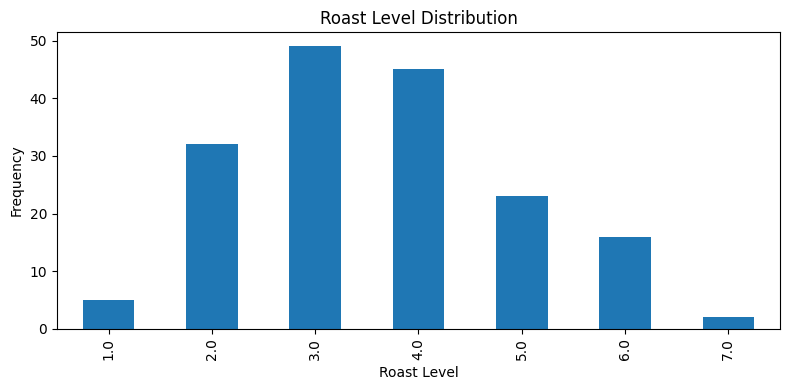

In [64]:
# Analyze roast level distribution
print("Unique roast level values:")
print(df_sub["Roast level"].value_counts().sort_index())

print("\nRoast level summary:")
print(df_sub["Roast level"].describe())

# Plot distribution
df_sub["Roast level"].value_counts().sort_index().plot(
    kind="bar",
    title="Roast Level Distribution"
)
plt.xlabel("Roast Level")
plt.ylabel("Frequency")
plt.show()


The distribution is heavily centered around 2-5, which means the dataset contains primarily light to medium roasts.
As the medium value is 3.5, 25th percentile is 3, 75th is 4. The dataset core cluster spans around 3-4. We are assigning 1-3 as light roast and 4-7 as medium/dark roast.
The reason we are assigning 1-3 as light is that level 3 has the highest count and at the boundary of 25th percentile. Level 4 and 5 straddle the median and is slightly darker but not too dark. They will be representing median roast. And 6,7 will be assigned to dark roast which has the lowest amount. Which correspond to the trait of dark roast, 'bold','strong' and 'bitter'. People are less preference on this strong characteristics.


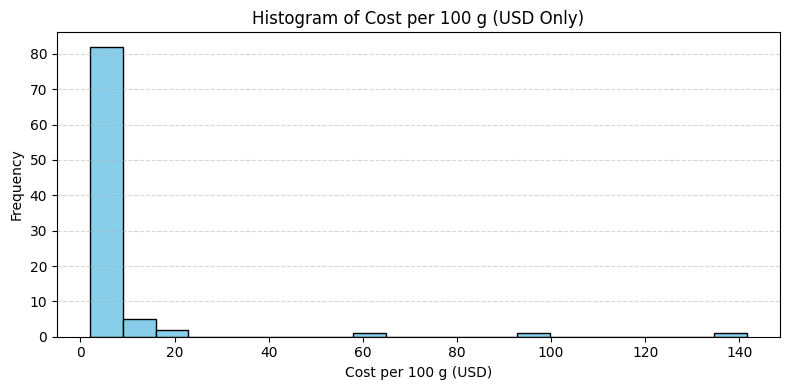

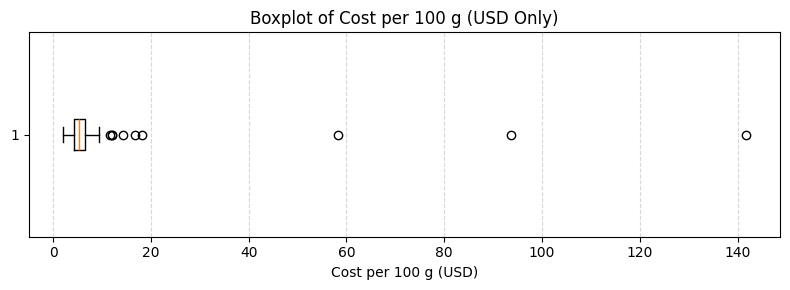

In [65]:
# Histogram
plt.figure(figsize=(8, 4))
plt.hist(cost_usd.dropna(), bins=20, color="skyblue", edgecolor="black")
plt.title("Histogram of Cost per 100 g (USD Only)")
plt.xlabel("Cost per 100 g (USD)")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

# Boxplot (to show outliers clearly)
plt.figure(figsize=(8, 3))
plt.boxplot(cost_usd.dropna(), vert=False)
plt.title("Boxplot of Cost per 100 g (USD Only)")
plt.xlabel("Cost per 100 g (USD)")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()


In [49]:
# Identify main cluster vs expensive outliers
cost_usd = df_usd["Cost per 100 g"]

# Percentiles for cluster vs outliers
p5 = cost_usd.quantile(0.05)
p95 = cost_usd.quantile(0.95)

print("5th percentile:", p5)
print("95th percentile:", p95)

# Main cluster
main_cluster = cost_usd[(cost_usd >= p5) & (cost_usd <= p95)]

# Outliers (expensive)
expensive_outliers = cost_usd[cost_usd > p95]

print("\nMain cluster count:", len(main_cluster))
print("Expensive outlier count:", len(expensive_outliers))
print("\nExpensive Outliers:")
print(expensive_outliers.sort_values(ascending=False))


5th percentile: 3.0
95th percentile: 15.425000000000008

Main cluster count: 83
Expensive outlier count: 5

Expensive Outliers:
135    141.67
44      93.75
52      58.33
91      18.16
65      16.80
Name: Cost per 100 g, dtype: float64


From the data and plot result, we can see that most of the coffee bean price lies within 4-6.5 USD per 100g. Which can be classified as affordable to mid-range. The mean 8.74 is higher than median 5.22, which means this is a right skewed distribution. Also there are extreme outliers, the highest value is 141.67 usd. A standard deviation of 17.8, which is almost 3 times higher than median further proves this skewness.
The percentile p5 is 3 usd and p95 is 15.425 usd. So value between p5-p95 should be normal range. Cheap should be cost below median(33 percentile ), and medium is from p33 - p95, expensive will be cost above p95.

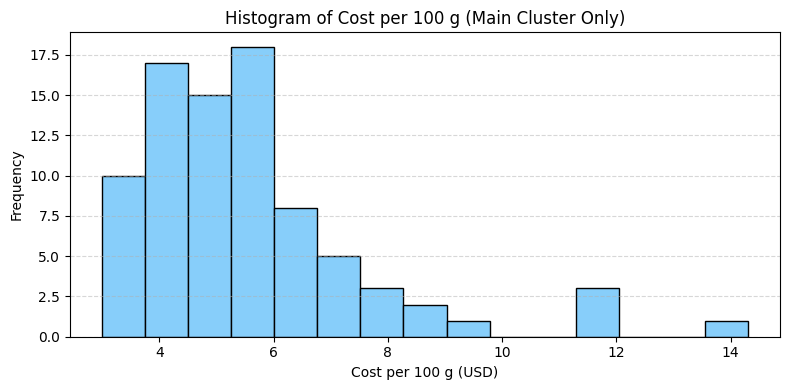

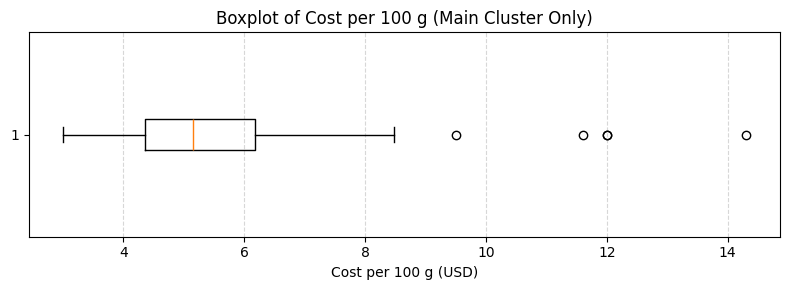

In [50]:
plt.figure(figsize=(8,4))
plt.hist(main_cluster, bins=15, color="lightskyblue", edgecolor="black")
plt.title("Histogram of Cost per 100 g (Main Cluster Only)")
plt.xlabel("Cost per 100 g (USD)")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

plt.figure(figsize=(8,3))
plt.boxplot(main_cluster, vert=False)
plt.title("Boxplot of Cost per 100 g (Main Cluster Only)")
plt.xlabel("Cost per 100 g (USD)")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()


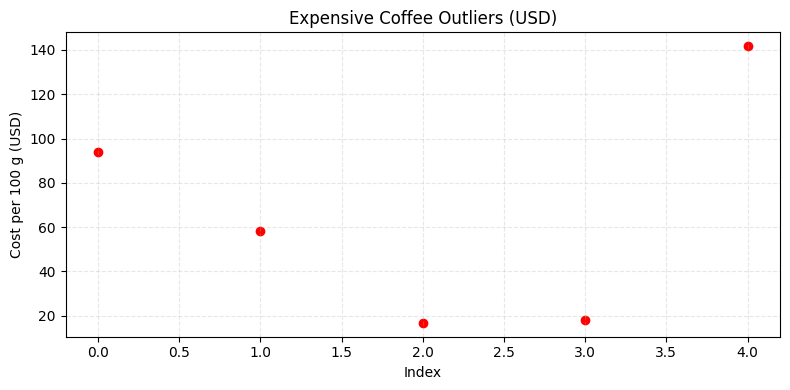

In [51]:
plt.figure(figsize=(8,4))
plt.scatter(range(len(expensive_outliers)), expensive_outliers, color="red")
plt.title("Expensive Coffee Outliers (USD)")
plt.xlabel("Index")
plt.ylabel("Cost per 100 g (USD)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


Rating summary:
count    172.000000
mean       7.988372
std        1.622172
min        1.000000
25%        7.000000
50%        8.000000
75%        9.000000
max       10.000000
Name: Rating, dtype: float64


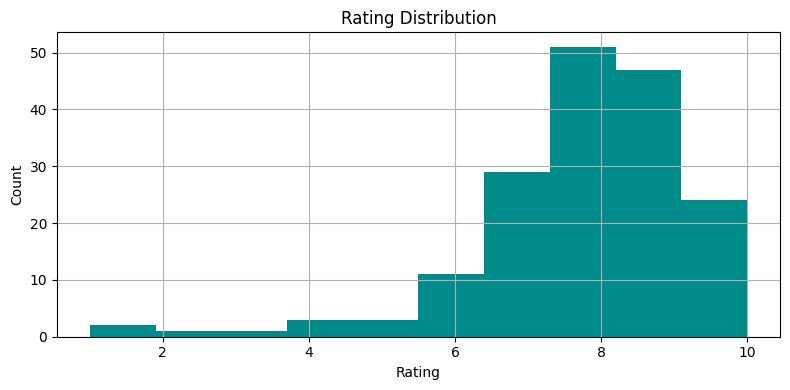

In [52]:
rating = pd.to_numeric(df_sub["Rating"], errors="coerce")

print("Rating summary:")
print(rating.describe())

rating.dropna().hist(bins=10, color="darkcyan")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


Top 15 Origins:
Origin
Blend          68
Colombia       23
Ethiopia       21
Brazil         16
Honduras        7
Costa Rica      7
India           7
Guatemala       6
Indonesia       5
Rwanda          3
Peru            3
China           2
Uganda          2
El Salvador     1
Kenya           1
Name: count, dtype: int64


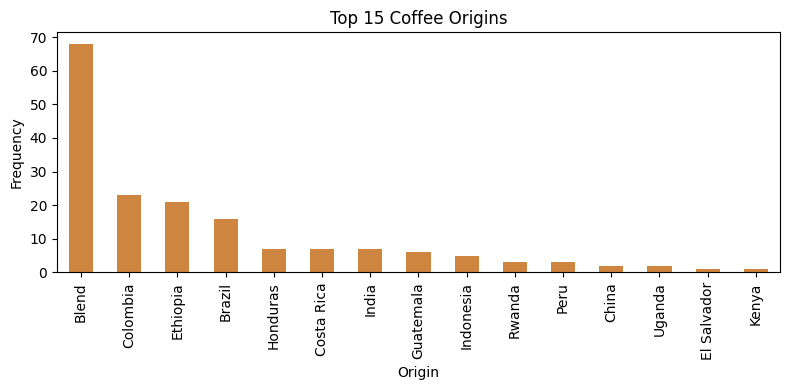

In [53]:
top_origins = df_sub["Origin"].value_counts().head(15)

print("Top 15 Origins:")
print(top_origins)

top_origins.plot(kind="bar", color="peru")
plt.title("Top 15 Coffee Origins")
plt.xlabel("Origin")
plt.ylabel("Frequency")
plt.show()


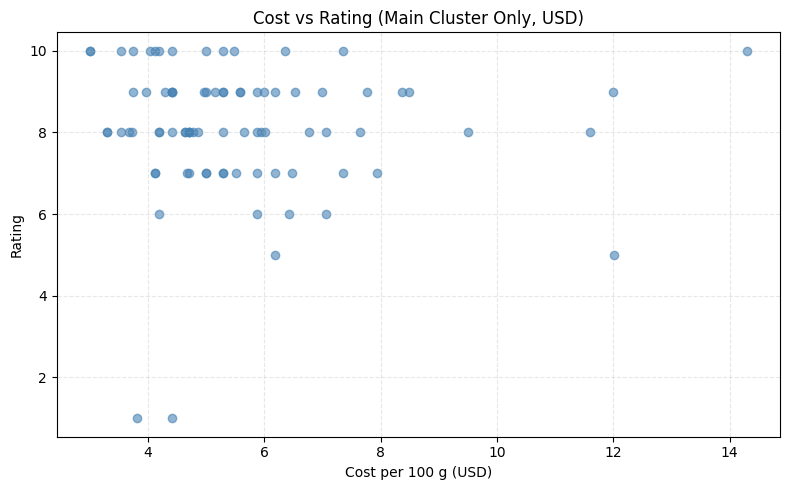

Main cluster points: 83


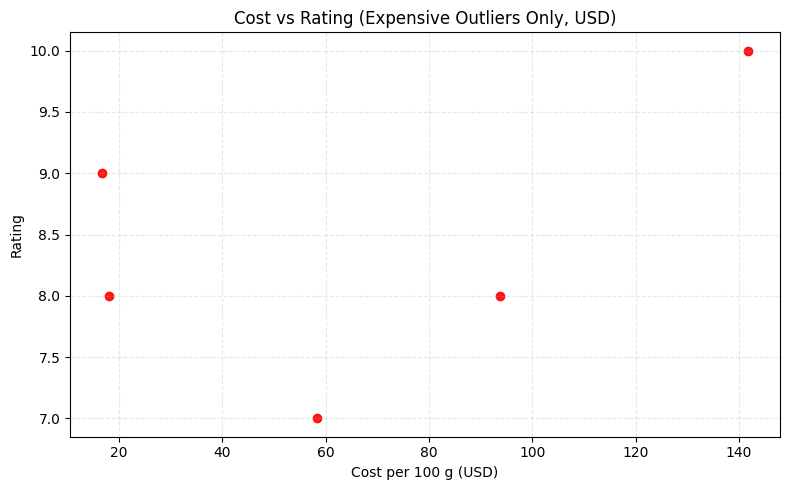

Expensive outlier points: 5
Expensive outlier price range:
135    141.67
44      93.75
52      58.33
91      18.16
65      16.80
Name: Cost per 100 g, dtype: float64


In [55]:
mask_main = (cost_usd >= p5) & (cost_usd <= p95) & rating.notna()

plt.figure(figsize=(8, 5))
plt.scatter(cost_usd[mask_main], rating[mask_main],
            alpha=0.6, color="steelblue")
plt.title("Cost vs Rating (Main Cluster Only, USD)")
plt.xlabel("Cost per 100 g (USD)")
plt.ylabel("Rating")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

print("Main cluster points:", mask_main.sum())

mask_expensive = (cost_usd > p95) & rating.notna()

plt.figure(figsize=(8, 5))
plt.scatter(cost_usd[mask_expensive], rating[mask_expensive],
            alpha=0.9, color="red")
plt.title("Cost vs Rating (Expensive Outliers Only, USD)")
plt.xlabel("Cost per 100 g (USD)")
plt.ylabel("Rating")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

print("Expensive outlier points:", mask_expensive.sum())
print("Expensive outlier price range:")
print(cost_usd[mask_expensive].sort_values(ascending=False))

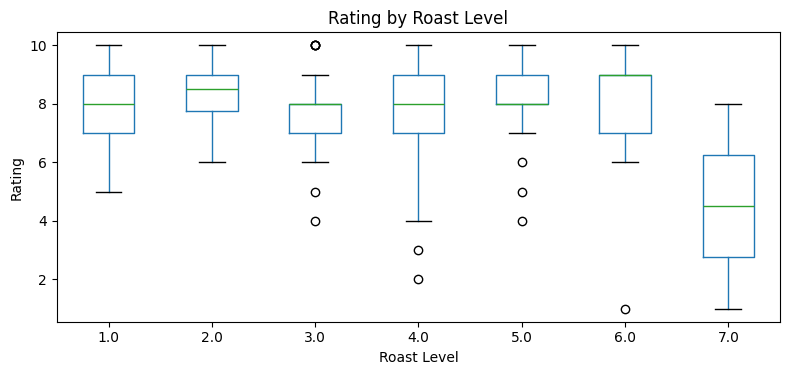

In [56]:
temp = df_sub.copy()
temp["rating_num"] = rating

valid_rows = temp.dropna(subset=["Roast level", "rating_num"])

valid_rows.boxplot(
    column="rating_num",
    by="Roast level",
    grid=False
)
plt.title("Rating by Roast Level")
plt.suptitle("")  # Remove automatic title
plt.xlabel("Roast Level")
plt.ylabel("Rating")
plt.show()


The charts are showing that there are no strong correlation between cost and rating. Beans wit different price can achieve similar ratings. It also shows that medium priced bean tend to have almost same quality as cheap beans. Rating is influenced more by bean characteristics. Cheap = good value, Medium = safe average choice,Expensive = rare, luxury items. Light and medium roasts consistently perform well and dark roast is less stable.

       keyword  frequency
0    chocolate         43
1          and         21
2      caramel         16
3         rich         16
4         body         14
5         dark         13
6      acidity         12
7       cherry          9
8       syrupy          9
9        nutty          8
10       sweet          8
11      finish          7
12           a          7
13        with          6
14       fruit          6
15         low          6
16          of          6
17      medium          6
18        very          6
19  chocolatey          5


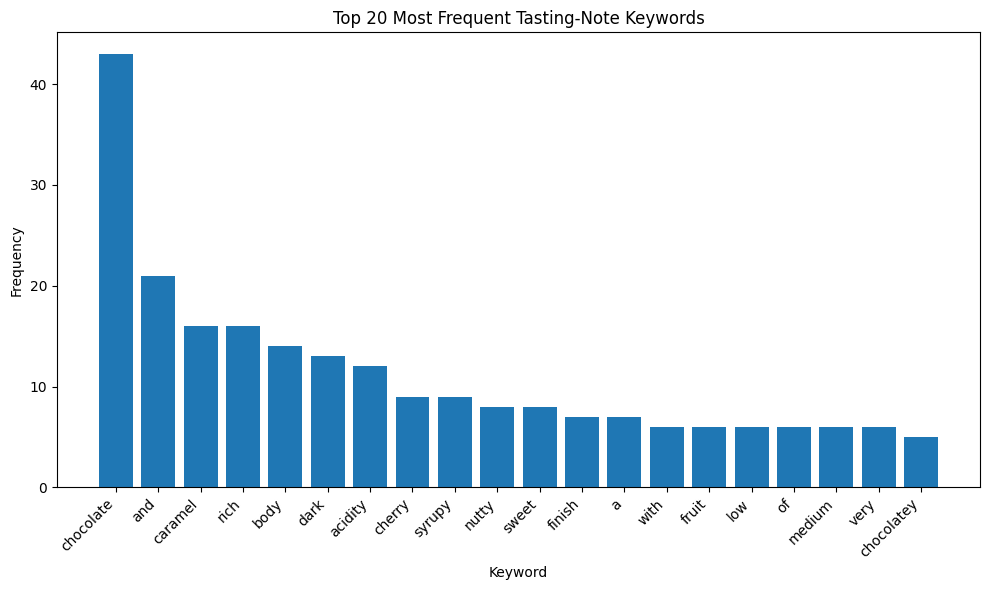

In [68]:
# Clean tasting notes
df_usd["Tasting notes"] = df_usd["Tasting notes"].fillna("").astype(str).str.strip()
df_usd["tasting_notes_norm"] = df_usd["Tasting notes"].str.lower()

def extract_taste_keywords(note_text: str):
    tokens = re.findall(r"[a-zA-Z]+", note_text.lower())
    return sorted(set(tokens))  # unique + sorted

df_usd["tasting_keywords"] = df_usd["tasting_notes_norm"].apply(extract_taste_keywords)

# Flatten all keyword lists to a single list
all_keywords = []
for kw_list in df_usd["tasting_keywords"]:
    all_keywords.extend(kw_list)

# Count frequency
keyword_counts = Counter(all_keywords)

# Convert to a DataFrame for cleaner viewing
df_keyword_freq = (
    pd.DataFrame(keyword_counts.items(), columns=["keyword", "frequency"])
    .sort_values(by="frequency", ascending=False)
    .reset_index(drop=True)
)

# Display top keywords
print(df_keyword_freq.head(20))

top_n = 20
plt.figure(figsize=(10,6))
plt.bar(df_keyword_freq["keyword"][:top_n], df_keyword_freq["frequency"][:top_n])
plt.xticks(rotation=45, ha='right')
plt.title(f"Top {top_n} Most Frequent Tasting-Note Keywords")
plt.xlabel("Keyword")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


Here are the most frequent keyword from taste_note, the useful keywords will be example keyword for user. When ever user have matched input, the agent will give correspond beans.